In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

In [ ]:
path = kagglehub.dataset_download("aklimarimi/audio-classifier-dataset")
print("Dataset path:", path)

100%|██████████| 4.75G/4.75G [00:59<00:00, 86.3MB/s]


Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root, len(files))

/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15 2
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio 0
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey 702
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Brene Brown 700
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Gary Vee 700
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Rabin Sharma 705
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Eckhart Tolle 730
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Simon Sinek 702
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Les Brown 700
/root/.cache/kagglehub/datasets/akli

In [ ]:
path = kagglehub.dataset_download("aklimarimi/audio-classifier-dataset")

In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files[:10]:  # show first 10 files
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/LICENSE
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/.gitignore
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/111Oprah Winfrey82.wav
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/323Oprah Winfrey5.wav
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/229Oprah Winfrey34.wav
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/146Oprah Winfrey127.wav
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/48Oprah Winfrey19.wav
/root/.cache/kagglehub/datasets/aklimarimi/audio-classifier-dataset/versions/15/augmented-audio/Oprah Winfrey/235Oprah Winfrey40.wav
/root/.cache/kagglehub/d

STEP 2: DATA PREPROCESSING

In [ ]:
# Import required libraries
import os

# Lists to store file paths and corresponding labels (speaker names)
audio_paths = []
labels = []

# Base path where dataset is stored
base_path = path + "/augmented-audio"

# Loop through each folder (each folder = one speaker/class)
for speaker in os.listdir(base_path):
    speaker_path = os.path.join(base_path, speaker)

    # Check if it's a directory
    if os.path.isdir(speaker_path):

        # Loop through each audio file in the speaker folder
        for file in os.listdir(speaker_path):
            if file.endswith(".wav"):  # consider only audio files

                # Store full file path
                audio_paths.append(os.path.join(speaker_path, file))

                # Store label (speaker name)
                labels.append(speaker)

# Print dataset information
print("Total audio files:", len(audio_paths))
print("Example label:", labels[0])

Total audio files: 7755
Example label: Oprah Winfrey


MFCC FEATURE EXTRACTION

In [ ]:
import librosa
import numpy as np

# List to store MFCC features
mfcc_features = []

# Loop through all audio files
for file in audio_paths:

    # Load audio file
    # sr=22050 means resampling to standard sampling rate
    audio, sr = librosa.load(file, sr=22050)

    # Extract MFCC features (13 coefficients)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)

    # Transpose to make shape = (time_steps, features)
    # LSTM expects time-series input
    mfcc = mfcc.T

    # Append to list
    mfcc_features.append(mfcc)

# Print shape of one sample
print("Example MFCC shape (time_steps, features):", mfcc_features[0].shape)

Example MFCC shape (time_steps, features): (216, 13)


PADDING SEQUENCES

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pad all sequences to make them equal length
# 'post' means padding at the end
# dtype=float32 ensures compatibility with TensorFlow
X = pad_sequences(mfcc_features, padding='post', dtype='float32')

print("Final input shape (samples, time_steps, features):", X.shape)

Final input shape (samples, time_steps, features): (7755, 216, 13)


LABEL ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Convert string labels (speaker names) into numeric values
le = LabelEncoder()
y = le.fit_transform(labels)

# Display all classes
print("Classes:", le.classes_)

Classes: ['Brene Brown' 'Eckhart Tolle' 'Eric Thomas' 'Gary Vee' 'Jay Shetty'
 'Les Brown' 'Mel Robbins' 'Nick Vujicic' 'Oprah Winfrey' 'Rabin Sharma'
 'Simon Sinek']


LSTM MODEL

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Initialize model
model = Sequential()

# LSTM layer:
# Learns temporal dependencies from MFCC sequences
model.add(LSTM(128, input_shape=(X.shape[1], X.shape[2])))

# Fully connected layer for learning complex patterns
model.add(Dense(64, activation='relu'))

# Output layer:
# Number of neurons = number of classes (speakers)
# Softmax gives probability distribution
model.add(Dense(len(set(y)), activation='softmax'))

# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',  # suitable for integer labels
    optimizer='adam',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        72,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,675 (319.04 KB)

 Trainable params: 81,675 (319.04 KB)

 Non-trainable params: 0 (0.00 B)

MODEL TRAINING

In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,   #20% → testing
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (6204, 216, 13)
Test: (1551, 216, 13)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# Create model
model = Sequential()

# Input layer (recommended)
model.add(Input(shape=(X.shape[1], X.shape[2])))

# LSTM layer
model.add(LSTM(128))

# Dense layers
model.add(Dense(64, activation='relu'))
model.add(Dense(len(set(y)), activation='softmax'))

# Compile model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 55s 274ms/step - accuracy: 0.5467 - loss: 1.5048 - val_accuracy: 0.7621 - val_loss: 0.8553
Epoch 2/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 52s 267ms/step - accuracy: 0.8259 - loss: 0.6304 - val_accuracy: 0.8427 - val_loss: 0.5626
Epoch 3/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 56s 289ms/step - accuracy: 0.8857 - loss: 0.4104 - val_accuracy: 0.8698 - val_loss: 0.4237
Epoch 4/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 52s 268ms/step - accuracy: 0.9110 - loss: 0.3130 - val_accuracy: 0.8878 - val_loss: 0.3616
Epoch 5/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 83s 273ms/step - accuracy: 0.9168 - loss: 0.2744 - val_accuracy: 0.8917 - val_loss: 0.3499
Epoch 6/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 66s 338ms/step - accuracy: 0.9292 - loss: 0.2375 - val_accuracy: 0.8827 - val_loss: 0.3832
Epoch 7/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 52s 266ms/step - accuracy: 0.9357 - loss: 0.2163 - val_accuracy: 0.9046 - val_loss: 0.2983
Epoch 8/20
194/194 ━━━━━━━━━━━━━━━━━━━━ 53s 273ms/step - accuracy: 0.9542 - loss: 0

EVALUATING MODEL

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

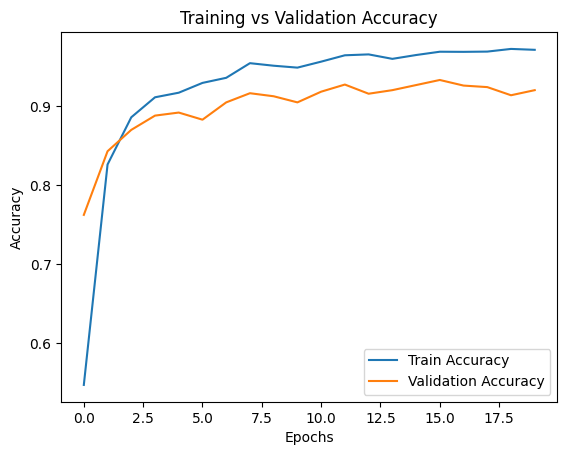

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [ ]:
# Save trained model
model.save("lstm_audio_model.h5")

In [22]:
model.save("lstm_audio_model.keras")

In [23]:
import tensorflow as tf

model = tf.keras.models.load_model("lstm_audio_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [24]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "lstm_audio_model.keras",
    compile=False   # <-- IMPORTANT
)

In [25]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [34]:
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

In [35]:
from google.colab import files

files.download("lstm_audio_model.keras")
files.download("label_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>